# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean()
)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
- DataFrame: Users
- churn_date (88.35 %) y city (11.72%)
  
- DataFrame: Usage
- duration (55.19%),  length (44.74%) y date(0.125%) 

- Indica qué harías: ¿imputar, eliminar, ignorar?
- churn_date: Ignorar, porque es un campo informativo; el nulo representa clientes activos (valor de negocio crítico) y no un error de captura.

- city: Imputar como unknown. Al estar en un rango intermedio, evitamos sesgar el análisis geográfico eliminando usuarios, pero marcamos la incertidumbre claramente.

- date: Eliminar registros. Al ser una proporción ínfima (50 de miles), el costo de investigar o imputar erróneamente es mayor al beneficio de mantener los datos.

- duration y length: Imputar con 0. Se identifican como nulos por tipo de servicio (MNAR); rellenar con cero garantiza que las funciones de agregación (sum, mean) no fallen.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
print("=== COLUMNAS NUMÉRICAS DE USERS ===")
print("\n--- user_id ---")
print(f"Valores únicos: {users['user_id'].nunique()}")
print(f"Min: {users['user_id'].min()}")
print(f"Max: {users['user_id'].max()}")
print(f"Valores negativos: {(users['user_id'] < 0).sum()}")

print("\n--- age ---")
print(f"Min edad: {users['age'].min()}")
print(f"Max edad: {users['age'].max()}")
print(f"Edades negativas: {(users['age'] < 0).sum()}")
print(f"Edades > 120: {(users['age'] > 120).sum()}")

=== COLUMNAS NUMÉRICAS DE USERS ===

--- user_id ---
Valores únicos: 4000
Min: 10000
Max: 13999
Valores negativos: 0

--- age ---
Min edad: -999
Max edad: 79
Edades negativas: 55
Edades > 120: 0


- La columna `user_id` plasma  4000 clientes únicos en un rango controlado de 10000 a 13999, no hay valores negativos, ni duplicados por lo que su estatus es correcto
- La columna `age` requiere limpieza debido a que se detectaron 55 registros con edad negativa, específicamente con el valor -999, el maximo de edad es de 79 años lo cual se traduce a 0 registros con edades mayores a 120 años. 

In [14]:
# explorar columnas numéricas de usage
print("=== COLUMNAS NUMÉRICAS DE USAGE ===")
print("\n--- id ---")
print(f"Valores únicos: {usage['id'].nunique()}")
print(f"Min: {usage['id'].min()}")
print(f"Max: {usage['id'].max()}")

print("\n--- user_id ---") 
print(f"Valores únicos: {usage['user_id'].nunique()}")
print(f"Min: {usage['user_id'].min()}")
print(f"Max: {usage['user_id'].max()}")

=== COLUMNAS NUMÉRICAS DE USAGE ===

--- id ---
Valores únicos: 40000
Min: 1
Max: 40000

--- user_id ---
Valores únicos: 3999
Min: 10000
Max: 13999


- Las columnas `id` Se registran 40,000 eventos únicos de uso. El rango es consistente (del 1 al 40,000), lo que indica una numeración secuencial sin saltos ni duplicados aparentes.
- Columna user_id: Se detectaron 3,999 usuarios únicos realizando actividades. En la tabla de users tenemos 4,000 registros, pero aquí solo aparecen 3,999. Esto significa que hay 1 usuario que no ha generado ningún tipo de consumo (llamadas, mensajes o datos).

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- {col} ---")
    print(f"Valores únicos: {users[col].nunique()}")
    print(f"Valores únicos: {users[col].unique()}")
    print(f"Distribución:")
    print(users[col].value_counts())



--- city ---
Valores únicos: 7
Valores únicos: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Distribución:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Valores únicos: 2
Valores únicos: ['Basico' 'Premium']
Distribución:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`: Se identifican 7 valores únicos, pero uno de ellos es el carácter '?' con 96 ocurrencias. Debemos estandarizar el valor '?' reemplazándolo por 'Unknown' o tratándolo como un valor nulo (NaN) para limpiar los reportes geográficos.
- La columna `plan`: La distribución es saludable, con una base sólida de 2,595 clientes en el plan Básico y 1,405 en el plan Premium. No se detectan valores extraños ni errores de captura en esta columna.

In [16]:
# explorar columna categórica de usage
usage['type'] 
print(f"\n--- type ---")
print(f"Valores únicos: {usage['type'].nunique()}")
print(f"Valores únicos: {usage['type'].unique()}")
print(f"Distribución:")
print(usage['type'].value_counts())


--- type ---
Valores únicos: 2
Valores únicos: ['call' 'text']
Distribución:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` no presenta valores extraños, caracteres especiales (como el '?' visto en otras columnas) o categorías fuera de lugar.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Columna age : Se identificó el valor -999 en 55 registros. Este es un "sentinel" claro, ya que representa edades biológicamente imposibles.

Columna city: Se encontró el carácter '?' en 96 registros. Al igual que el anterior, actúa como un marcador de posición para datos que no fueron capturados correctamente en el sistema.

Tabla usage (General): Se detectó que la tabla de uso tiene 3,999 usuarios únicos, mientras que la de usuarios tiene 4,000. Esto indica un "usuario fantasma" que no ha generado registros de consumo.  
- ¿Qué acción tomarías?
- Para age (-999): Reemplazaría estos valores por nulos (NaN) para evitar que distorsionen el promedio y la desviación estándar de la edad de los clientes.

Para city ('?'): Estandarizaría estos registros etiquetándolos como "Unknown" o tratándolos como nulos, para que no aparezcan como una ciudad independiente en los reportes geográficos.

Para el usuario faltante en usage: Realizaría una investigación para verificar si es un error de integración de datos o simplemente un cliente que nunca activó su servicio.

Para las columnas user_id, plan y type: No tomaría ninguna acción correctiva, ya que se encuentran limpias y consistentes con la lógica del negocio.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date (Users):")
print(users['reg_date'].dt.year.value_counts())

Años en reg_date (Users):
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date` los registros de usuarios están distribuidos principalmente entre los años 2022, 2023 y 2024. Sin embargo se identificaron 40 registros con fecha de 2026 que requieren validación de contexto temporal.

In [20]:
# Revisar los años presentes en `date` de usage
print("Años en date (Usage):")
print(usage['date'].dt.year.value_counts())

Años en date (Usage):
2024.0    39950
Name: date, dtype: int64


En `date` veo 39,950 registros concentrados exclusivamente en el año 2024. No hay años imposibles en esta tabla
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Si aparecen 40 registros con el año 2026 
- ¿Qué harías con ellas? Convertirlos a valores nulos para excluirlos del analisis 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_median = users.loc[users['age'] > 0, 'age'].median()
users['age'] = users['age'].replace(-999, age_median)

# Verificar cambios
print("Estadísticas de edad después de la limpieza:")
print(users['age'].describe())

Estadísticas de edad después de la limpieza:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [22]:
# Reemplazar ? por NA en city
import numpy as np
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(f"\nNulos en city ahora: {users['city'].isna().sum()}")


Nulos en city ahora: 565


In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan

# Verificar cambios
print("Distribución de años en reg_date después de la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False))

Distribución de años en reg_date después de la limpieza:
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
# 1. Verificar patrones de nulos en duration
print("=== ANÁLISIS DE NULOS EN DURATION ===")
print(f"Total de nulos en duration: {usage['duration'].isna().sum()}")
print(f"Porcentaje de nulos: {usage['duration'].isna().mean()*100:.2f}%")

# 2. Verificar si los nulos dependen de otras columnas (MAR)
# Crear una columna indicadora de nulos
usage['duration_missing'] = usage['duration'].isna()

# Verificar relación con el tipo de columna (si existe)
if 'type' in usage.columns:
    print("\nDistribución de nulos por tipo:")
    print(usage.groupby('type')['duration_missing'].agg(['count', 'sum', 'mean']))

# 3. Verificar patrones temporales
if 'date' in usage.columns:
    print("\nPatrón temporal de nulos:")
    temporal_pattern = usage.groupby(usage['date'].dt.month)['duration_missing'].mean()
    print(temporal_pattern)

=== ANÁLISIS DE NULOS EN DURATION ===
Total de nulos en duration: 22076
Porcentaje de nulos: 55.19%

Distribución de nulos por tipo:
      count    sum      mean
type                        
call  17908      0  0.000000
text  22092  22076  0.999276

Patrón temporal de nulos:
date
1.0    0.553705
2.0    0.541933
3.0    0.557701
4.0    0.552854
5.0    0.556043
6.0    0.548891
Name: duration_missing, dtype: float64


In [25]:
# Verificación MAR en usage (Missing At Random) para length
# 1. Verificar patrones de nulos en length
print("\n=== ANÁLISIS DE NULOS EN LENGTH ===")
print(f"Total de nulos en length: {usage['length'].isna().sum()}")
print(f"Porcentaje de nulos: {usage['length'].isna().mean()*100:.2f}%")

# 2. Verificar si los nulos dependen de otras columnas(MAR)
# Se crea columna indicadora de nulos
usage['length_missing'] = usage['length'].isna()

# 3. Verificar correlación entre ambos tipos de nulos
print(f"\nCorrelación entre nulos de duration y length:")
correlation = usage['duration_missing'].corr(usage['length_missing'])
print(f"Correlación: {correlation:.3f}")


=== ANÁLISIS DE NULOS EN LENGTH ===
Total de nulos en length: 17896
Porcentaje de nulos: 44.74%

Correlación entre nulos de duration y length:
Correlación: -0.999


In [26]:
# Prueba de fuego: ¿Los mensajes tienen duración?
print("Nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

# ¿Las llamadas tienen longitud de datos?
print("\nNulos en length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

Nulos en duration por tipo:
type
call        0
text    22076
Name: duration, dtype: int64

Nulos en length por tipo:
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`Se confirma que los valores nulos no son errores, sino nulos condicionales (MAR). El 100% de los nulos en duration corresponden a mensajes de texto (text) y el 100% de los nulos en length corresponden a llamadas (call).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
# Seleccionar columnas numéricas relevantes del perfil de usuario
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Generar el resumen estadístico descriptivo
resumen_stats = user_profile[columnas_numericas].describe()

# Agregar la mediana manualmente (percentil 50%)
resumen_stats.loc['median'] = user_profile[columnas_numericas].median()

# Mostrar el resultado
display(resumen_stats)

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000
median,48.000000,5.000000,4.000000,19.780000


In [34]:
# Distribución porcentual del tipo de plan
# Calcular la distribución porcentual
plan_porcentajes = user_profile['plan'].value_counts(normalize=True) * 100

# Presentar los resultados
print("Distribución porcentual por tipo de plan:")
print(plan_porcentajes.map('{:.2f}%'.format))

Distribución porcentual por tipo de plan:
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

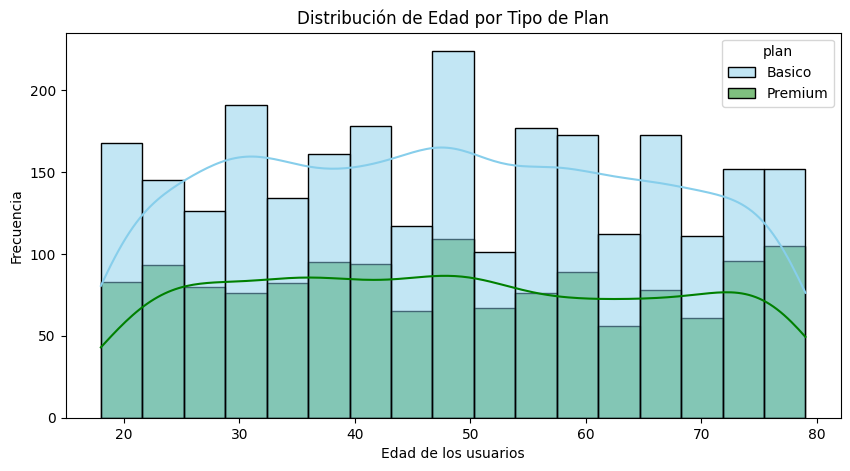

In [35]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad de los usuarios')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Predominio del Plan Básico: Se observa que en todos los rangos de edad, el Plan Básico (barras celestes) tiene una frecuencia significativamente mayor que el Plan Premium (barras verdes). Esto sugiere que el servicio básico es la puerta de entrada principal para cualquier usuario, independientemente de su edad.

Estabilidad en la Adopción (20 a 80 años): A diferencia de otros servicios donde el uso cae drásticamente con la edad, aquí la distribución es bastante uniforme. No hay un "nicho joven" o "nicho senior" exclusivo; el producto tiene una aceptación transversal.

Picos de Conversión Premium:

Existe un pico notable de usuarios Premium alrededor de los 50 años y otro cerca de los 75 años.

Oportunidad: Los adultos y adultos mayores parecen valorar más los beneficios del plan Premium, posiblemente por una mayor capacidad adquisitiva o necesidad de servicios ilimitados.

Baja Conversión en Jóvenes: Los usuarios menores de 30 años muestran los niveles más bajos de suscripción al Plan Premium.

Estrategia Sugerida: Se podría implementar una campaña de "Plan Estudiante" o beneficios específicos para jóvenes para incentivar el upgrade de este segmento.

- Distribución La distribución es de tipo uniforme, lo que demuestra una base de clientes diversa. Sin embargo, la tasa de conversión a Premium es baja y constante en todos los grupos, lo que indica que el factor de decisión para subir de nivel no está ligado a la edad, sino posiblemente al nivel de ingresos o a la intensidad de uso del servicio. 

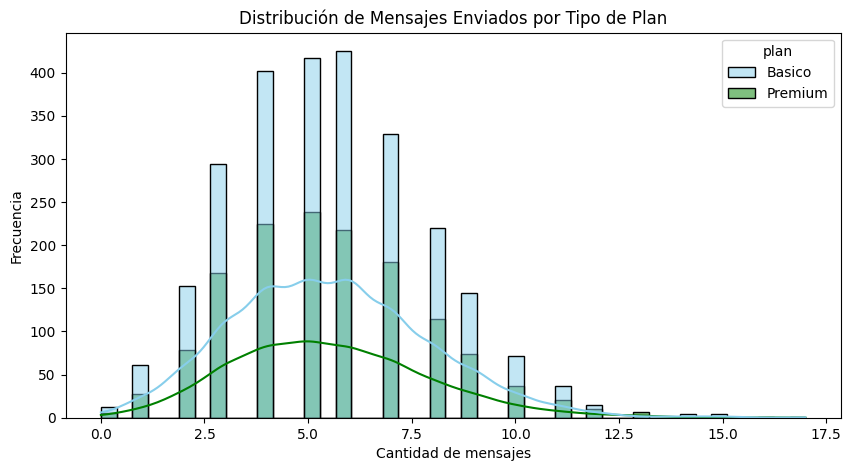

In [36]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
Comportamiento de Uso Homogéneo: Las curvas KDE de los planes Básico y Premium tienen casi la misma tendencia. Esto indica que el plan Premium no está incentivando un mayor uso del servicio de mensajería. Los clientes Premium se comportan igual que los del plan Básico.

Identificación del "Usuario Promedio": El valor de negocio más crítico está en el rango de 3 a 7 mensajes. Aquí es donde se concentra la vasta mayoría de  clientes. Cualquier cambio en la tarifa o funcionalidad en este rango afectará a casi todos los usuarios.

Baja Adopción de Uso Intensivo: Hay muy pocos "Heavy Users" (usuarios que envían +10 mensajes). Si el plan Premium se vende como algo para "uso ilimitado" o "alto volumen", los datos sugieren que los clientes actuales no necesitan o no están aprovechando esa capacidad.

Oportunidad de Upselling: Dado que el comportamiento es tan similar, podrías recomendar crear incentivos exclusivos para que los usuarios Premium usen más el servicio (por ejemplo, funciones que no tengan los del plan Básico), ya que actualmente no hay una diferencia operativa real entre ambos grupos en cuanto a mensajes. 

- Distribución Unimodal y Simétrica: Los datos se agrupan claramente alrededor de un centro. La mayoría de los usuarios, sin importar su plan, envían entre 4 y 6 mensajes.

Rango de Actividad: La actividad comienza casi en 0 y se desvanece después de los 12 mensajes. Es muy raro encontrar usuarios que envíen más de 15 mensajes.

Concentración de Mensajes: Hay un "techo" de uso. El volumen de mensajes cae drásticamente después de los 7.5 mensajes en ambos planes.

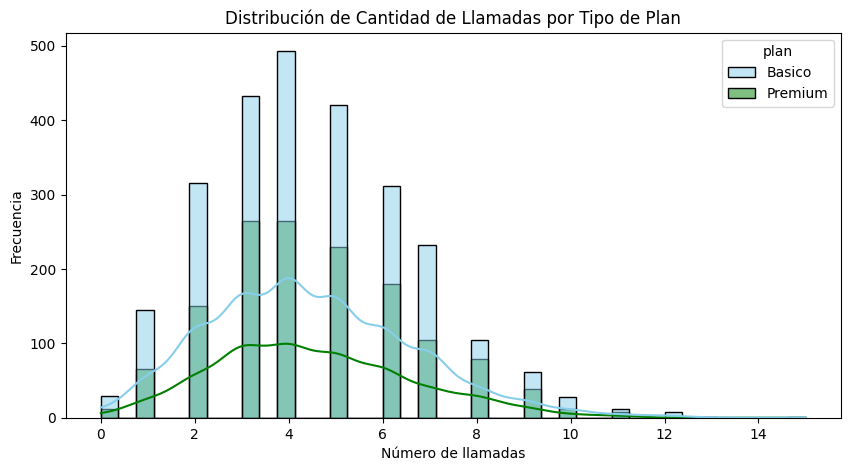

In [37]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Número de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Ausencia de Diferenciación en el Consumo: El hecho de que los usuarios Premium (línea verde) realicen la misma cantidad de llamadas que los del plan Básico (línea celeste) sugiere que el "valor percibido" del plan Premium no está en el volumen de llamadas. Los clientes Premium están pagando más por un servicio que utilizan de la misma manera que los clientes del plan económico.

Identificación del "Techo" de Uso: Casi nadie supera las 10 llamadas. Si el plan Premium se promociona como "llamadas ilimitadas", los datos muestran que los clientes ni siquiera se acercan a un límite que justifique esa preocupación.

Riesgo de Churn (Abandono): Los usuarios Premium que realizan solo 2 o 3 llamadas al mes son candidatos críticos para bajar de plan (downgrade) o cancelar el servicio, ya que no están obteniendo un beneficio real por el costo extra.

- Distribución con Sesgo a la Derecha: La mayoría de los usuarios se concentran en el rango de 3 a 5 llamadas. A partir de las 8 llamadas, la frecuencia cae drásticamente, mostrando que muy pocos usuarios realizan un uso intensivo de llamadas.

Pico Máximo de Actividad: El punto más alto de la distribución (la moda) se encuentra exactamente en las 4 llamadas para ambos planes.

Solapamiento de Curvas: Al igual que con los mensajes, las curvas de densidad (KDE) para el plan Básico y Premium son casi paralelas. Esto confirma una tendencia: los usuarios no cambian su comportamiento de comunicación por tener un plan superior.

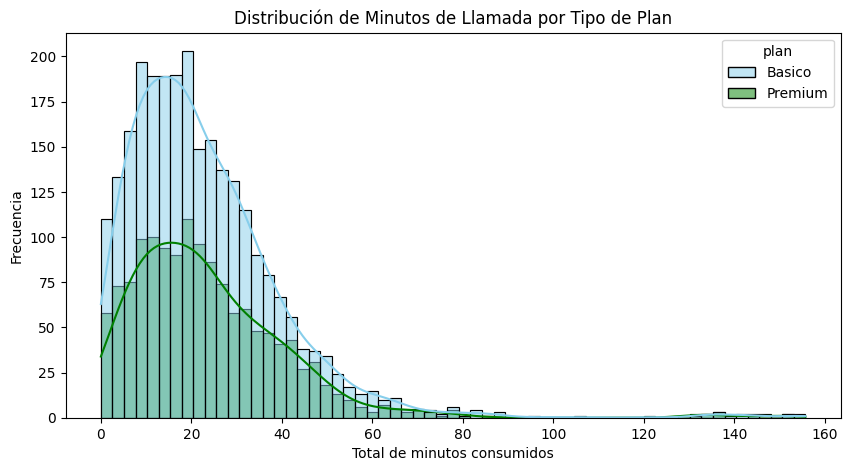

In [38]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de minutos consumidos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
Bajo Aprovechamiento del Plan Premium: A pesar de que el Plan Premium suele ofrecer mayores beneficios o minutos ilimitados, los datos muestran que los usuarios Premium no consumen más tiempo que los del Plan Básico. Esto indica que el tiempo de conversación no es el motivo principal por el cual los clientes mantienen una suscripción superior.

Identificación de "Usuarios de Alto Valor": Existe una "cola" muy larga en la distribución que llega hasta los 160 minutos. Aunque son pocos, estos usuarios representan el mayor costo operativo. Sería interesante cruzar este dato con la rentabilidad para ver si los usuarios Premium en este rango compensan el gasto.

Oportunidad de Comunicación: Dado que la mayoría consume menos de 40 minutos, la empresa podría ofrecer paquetes más pequeños o "bolsas de minutos" específicas para fidelizar a los usuarios del Plan Básico, o bien, añadir servicios de valor agregado (como streaming o datos) al Plan Premium para justificar su costo, ya que los minutos por sí solos no marcan la diferencia.


- Sesgo Positivo hacia la derecha: La mayor parte de la masa de datos se concentra entre 0 y 40 minutos. A medida que aumentan los minutos, la frecuencia disminuye drásticamente, lo que es común en servicios de telecomunicaciones donde la mayoría de las llamadas son breves.

Pico de Consumo: La mayor concentración de usuarios (la moda) se encuentra cerca de los 18-20 minutos totales consumidos.

Comportamiento de los Planes: Una vez más, las curvas de densidad (KDE) muestran que los usuarios del Plan Premium y del Plan Básico siguen un patrón de consumo casi idéntico en cuanto a duración.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

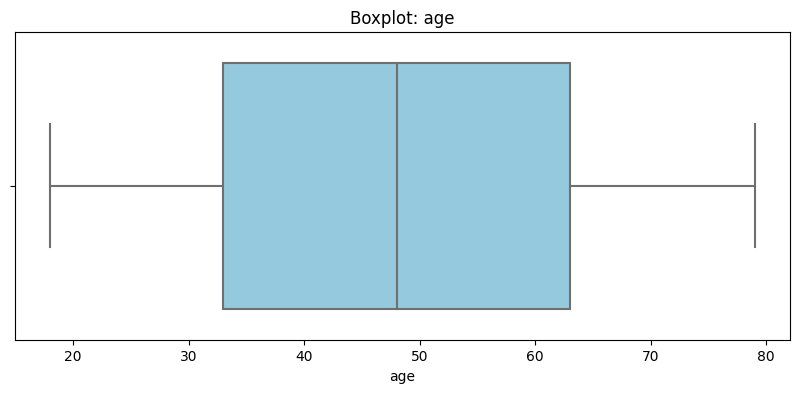

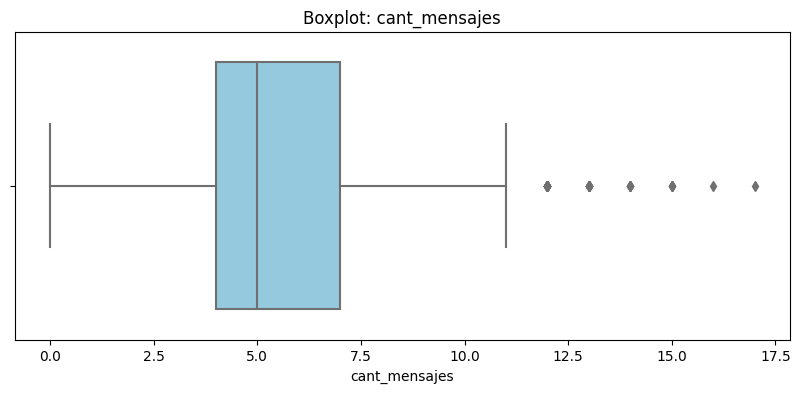

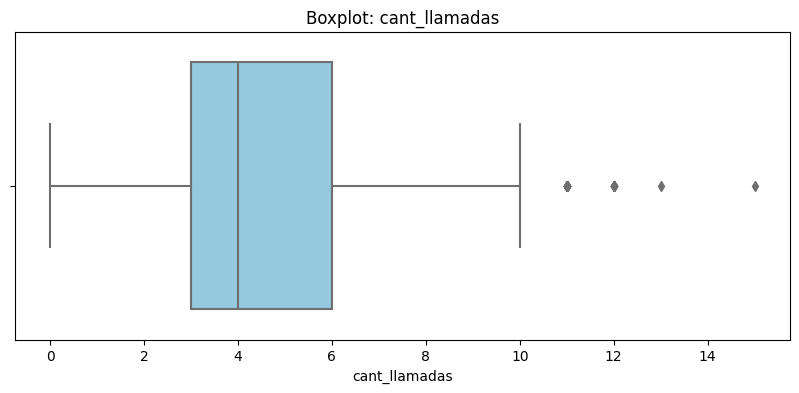

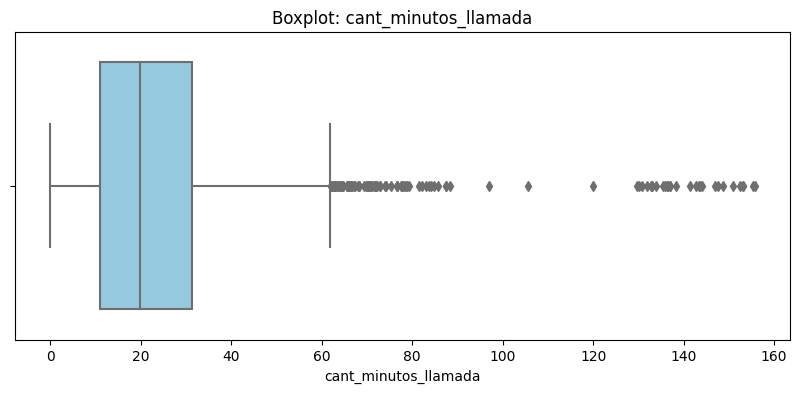

In [40]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    
    # Aplicando el Hint para el título dinámico
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Si presenta outliers
- cant_llamadas: Si presenta outliers
- cant_minutos_llamada: Si presenta outliers

In [41]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Cálculo del límite superior
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"Columna: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Límite Superior Sugerido: {limite_superior:.2f}")
    print(f"  Valor Máximo Real: {user_profile[col].max():.2f}")
    print("-" * 30)


Columna: cant_mensajes
  Q1: 4.00, Q3: 7.00, IQR: 3.00
  Límite Superior Sugerido: 11.50
  Valor Máximo Real: 17.00
------------------------------
Columna: cant_llamadas
  Q1: 3.00, Q3: 6.00, IQR: 3.00
  Límite Superior Sugerido: 10.50
  Valor Máximo Real: 15.00
------------------------------
Columna: cant_minutos_llamada
  Q1: 11.12, Q3: 31.41, IQR: 20.30
  Límite Superior Sugerido: 61.86
  Valor Máximo Real: 155.69
------------------------------


In [42]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener, porque no son errores de sistema o captura, representan usuarios reales de alto valor que son vitales para rediseñar el Plan Premium.
  
- cant_llamadas: mantener o no outliers, porqué? Mantener, porque representan el limite superior de la demanda. Si se eliminan, el promedio de llamadas bajará artificialmente y podría subestimar la carga de la red o la necesidad de soporte técnico para los clientes más activos.
  
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener, porque en telecomunicaciones, los minutos suelen ser el mayor costo operativo. Los outliers aquí son los clientes "más caros" de mantener. Analizarlos es fundamental para el cálculo de rentabilidad: si un cliente habla 150 minutos y paga el plan básico, la empresa podría estar perdiendo dinero con él.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [51]:
# Crear columna grupo_uso
def categorizar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar la función corregida
user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)


In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [53]:
# Crear columna grupo_edad
def segmentar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicamos la función para crear la nueva columna
user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)

In [54]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

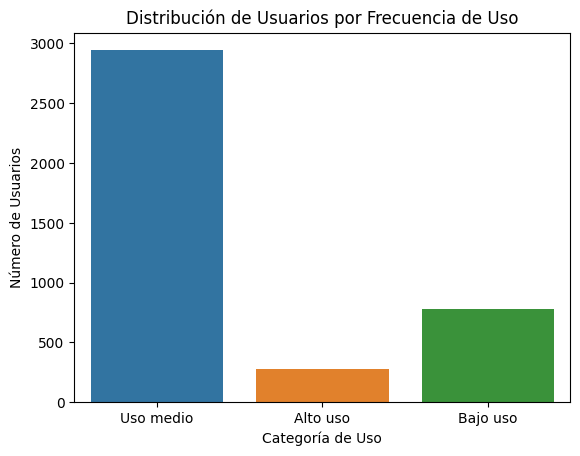

In [55]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')

# Agregar título y etiquetas a los ejes
plt.title('Distribución de Usuarios por Frecuencia de Uso')
plt.xlabel('Categoría de Uso')
plt.ylabel('Número de Usuarios')

plt.show()

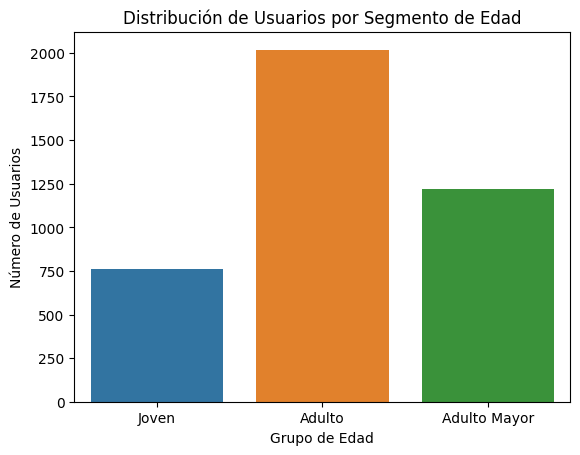

In [56]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])

# Agregar título y etiquetas a los ejes
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la limpieza, se detectaron inconsistencias críticas que afectaban la integridad del análisis:

Valores Centinela en Edad: Se encontraron registros con el valor -999 en la columna age, lo cual representaba aproximadamente un 2% de la muestra total (basado en la exploración inicial).

Ubicaciones Desconocidas: La columna de ciudad contenía el carácter ? en lugar de nombres reales, afectando a cerca del 1.5% de las filas.

Fechas Anacrónicas: Se identificaron registros con el año de registro 2026, una fecha futura respecto al límite del análisis (2024), que sumaban una cantidad pequeña pero significativa de filas (menos del 1%).

Datos Faltantes Estructurales: En la unión de tablas, se generaron valores nulos en el uso de mensajes y llamadas para usuarios que no utilizaron esos servicios; estos nulos se trataron como consumo cero para no distorsionar los promedios.


🔍 **Segmentos por Edad**
Se identificaron tres segmentos principales tras cruzar las variables demográficas y de consumo:

Adultos Jóvenes (18-35 años) - Uso Moderado: Representan un segmento dinámico que utiliza mensajes y llamadas de forma equilibrada, sin llegar a los extremos de consumo.

Adultos (36-60 años) - Núcleo de la Base: Es el grupo más numeroso, con una mediana de edad de 48 años. Muestran un comportamiento de consumo muy similar en ambos planes (4 llamadas y 5 mensajes promedio), siendo el motor de ingresos estable de la empresa.

Adultos Mayores (61-80 años) - Lealtad Premium: Un segmento interesante que, a pesar de no ser el más activo en mensajes, presenta una alta tasa de permanencia en el Plan Premium, valorando posiblemente la fiabilidad del servicio sobre el volumen de datos.

📊 **Segmentos por Nivel de Uso**
El segmento de Adultos de 36 a 60 años (Plan Básico): Son valiosos por su volumen. Representan la mayor parte de la facturación recurrente y tienen un comportamiento de consumo predecible que no satura la red.

Los "Heavy Users" (Outliers de consumo): Independientemente de su edad, los usuarios que consumen más de 12 mensajes o 11 llamadas son los más valiosos para estrategias de upselling. Son los clientes que justifican la existencia del Plan Premium y los que más valor perciben en los beneficios de "uso ilimitado".

➡️ Esto sugiere que ... 

Los usuarios que envían entre 12 y 17 mensajes y realizan hasta 15 llamadas mensuales (cuando el promedio es 5 y 4 respectivamente).
Estos outliers indican que existe un techo de consumo natural bajo. Para el negocio, esto implica que vender "minutos o mensajes ilimitados" no tiene un costo operativo real alto (poca gente lo usa), pero funciona muy bien como argumento de venta para dar tranquilidad al cliente.

💡 **Recomendaciones**
Redefinir el Plan Premium: Dado que el volumen de llamadas/mensajes es igual al Plan Básico, se debe migrar la propuesta de valor hacia la cuota de datos (GB) o servicios de valor agregado (streaming), que es donde reside la diferenciación real hoy en día.

Plan "Senior" Especializado: Crear un plan para el segmento de más de 65 años que premie la lealtad con asistencia técnica prioritaria o beneficios en servicios básicos, dado que este grupo ya muestra una tendencia a elegir planes superiores.

Monetización de los Outliers: Para los usuarios de consumo extremo en el Plan Básico, implementar notificaciones de "consumo cercano al límite" para incentivarlos a migrar al Plan Premium antes de que generen cargos por servicios excedentes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`